# Student Information

| Field       | Details              |
|-------------|----------------------|
| **Name**    | Nimesh Timalsina     |
| **Roll No** | 26                   |

---

# SE Attention Mechanism with YOLOv8

## Overview

This notebook investigates whether injecting **Squeeze-and-Excitation (SE)** channel attention into a YOLOv8 backbone changes detection performance on Pascal VOC. Two YOLOv8n models are compared under identical training conditions.

| Model | Description |
|-------|-------------|
| **Baseline** | Standard YOLOv8n fine-tuned from COCO pretrained weights |
| **SE-Enhanced** | YOLOv8n with SE blocks wrapped around 6 backbone Conv layers |

## Objectives

1. Understand YOLOv8's Conv-based backbone module structure.
2. Implement an `SEConvWrapper` that appends SE attention after selected Conv modules.
3. Train both models for 10 epochs on 500 VOC train / 100 VOC val images.
4. Compare Precision, Recall, mAP@0.5, mAP@0.5:0.95, speed, and parameters.
5. Analyze why SE injection changes (or fails to change) YOLOv8 performance.

## Experimental Setup

| Setting | Value |
|---------|-------|
| Dataset | Pascal VOC 2012 (500 train / 100 val) |
| YOLO variant | YOLOv8n (nano — fastest, fewest parameters) |
| SE injection | 6 backbone Conv layers in C2f blocks at layers 2, 4, 6 |
| Epochs | 10 |
| Batch size | 16 |
| Image size | 640 × 640 |
| Initial LR | 0.01 (cosine decay) |
| Hardware | NVIDIA GPU (CUDA) |

## Outline

| Step | Description |
|------|-------------|
| 1 | Install dependencies |
| 2 | Imports & global config (torch.load compatibility patch) |
| 3 | Dataset: Pascal VOC → YOLO format conversion |
| 4 | Train **Baseline YOLOv8** (no attention) |
| 5 | Implement **SE Block** |
| 6 | Patch SE into YOLOv8 backbone Conv layers |
| 7 | Train **SE-Enhanced YOLOv8** |
| 8 | Evaluate both models (Precision, Recall, mAP@0.5, mAP@0.5:0.95) |
| 9 | Results table & loss curves |
| 10 | Side-by-side predictions |
| 11 | Inference speed benchmark |

## SE Insertion Point — YOLOv8 Backbone Conv Layers

In YOLOv8, the fundamental building block is the `Conv` module: `Conv2d → BatchNorm → SiLU`. This notebook wraps selected `Conv` blocks with SE attention appended **after** the full Conv-BN-SiLU activation:

```
Original YOLOv8 Conv block:
Input → Conv2d → BatchNorm → SiLU → Output

After SE wrapping (SEConvWrapper):
Input → Conv2d → BatchNorm → SiLU → SEBlock → Output
                                         ↑
                                  added HERE (after activation)
```

**Target layers:** `cv1` and `cv2` inside C2f modules at backbone positions 2, 4, and 6 — the early-to-mid backbone where channel semantics are still evolving and SE recalibration is most impactful.

**What SE does at each wrapped Conv:**
```
After SiLU:  feature map [B, C, H, W]
    ↓  Squeeze:  AdaptiveAvgPool2d(1)  →  [B, C]
    ↓  Excite:   FC(C→C/16) → ReLU → FC(C/16→C) → Sigmoid  →  [B, C] ∈ (0,1)
    ↓  Scale:    feature_map × weights.view(B,C,1,1)  →  [B, C, H, W]
```

**Why these 6 layers specifically?**
- C2f blocks 2, 4, 6 are the first three down-sampling stages — channels grow from 32→64→128, making per-channel weights meaningful.
- Later layers (neck, head) participate in `model.fuse()` which bypasses SE wrappers — injecting SE there has no effect after fusion.

**Known limitation:** Ultralytics calls `model.fuse()` before `val()`, which removes BN and merges Conv+BN into a single Conv2d. SE wrappers outside this fusion chain may be bypassed, causing the validation model to effectively run without SE. This is analyzed in the results section.

## Step 1 — Install Dependencies

Required packages:

| Package | Version | Purpose |
|---------|---------|---------|
| `ultralytics` | 8.2.0 (pinned) | YOLOv8 training, evaluation, and inference API |
| `torch` + `torchvision` | latest | PyTorch backend; torchvision needed for VOC download |
| `pycocotools` | latest | COCO-format metrics used internally by Ultralytics |
| `Pillow` | latest | Image loading for prediction visualisation |
| `matplotlib` | latest | Plotting charts and prediction grids |
| `PyYAML` | latest | Writing the dataset configuration YAML file |

> **Version pin:** `ultralytics==8.2.0` is pinned because the SE injection uses internal module names (`ultralytics.nn.modules.conv.Conv`) that may change across versions. Using a different version may cause the injection step to silently skip all layers.

In [ ]:
!pip install ultralytics==8.2.0 torch torchvision
# For dataset conversion
!pip install pycocotools Pillow matplotlib PyYAML

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.8/750.8 kB 12.5 MB/s eta 0:00:00


## Step 2 — Imports & Global Configuration

### torch.load Compatibility Patch

PyTorch ≥ 2.6 sets `weights_only=True` by default in `torch.load`, which breaks Ultralytics' `.pt` checkpoint loading (checkpoints are pickled arbitrary objects). The monkey-patch forces `weights_only=False` for all `torch.load` calls in this session so that pretrained weights load correctly.

### Key Configuration

| Variable | Value | Description |
|----------|-------|-------------|
| `YOLO_VARIANT` | `yolov8n` | Nano variant — 3M params, fastest training; swap to `yolov8s/m` for more capacity |
| `EPOCHS` | 10 | Same for both models to ensure fair comparison |
| `IMG_SIZE` | 640 | YOLOv8 standard training resolution |
| `BATCH_SIZE` | 16 | Standard for 640×640 on a T4 GPU |
| `LR0` | 0.01 | Ultralytics default initial LR; cosine decay applied automatically |
| `DATA_DIR` | `voc_yolo/` | Root directory for the converted YOLO-format dataset |
| `DEVICE` | `0` (GPU) or `'cpu'` | GPU index 0 if CUDA is available |

In [ ]:
import os, shutil, time, yaml, random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

# PyTorch >= 2.6 sets weights_only=True by default, which breaks Ultralytics .pt loading.
# This patch forces weights_only=False so pretrained checkpoints load correctly.
_original_torch_load = torch.load
def _patched_torch_load(f, *args, **kwargs):
    kwargs['weights_only'] = False
    return _original_torch_load(f, *args, **kwargs)
torch.load = _patched_torch_load

from ultralytics import YOLO

YOLO_VARIANT  = 'yolov8n'   # n=nano | s=small | m=medium
EPOCHS        = 10
IMG_SIZE      = 640
BATCH_SIZE    = 16
LR0           = 0.01
DATA_DIR      = Path('voc_yolo')

if torch.cuda.is_available():
    DEVICE = 0          # CUDA GPU index
elif torch.backends.mps.is_available():
    DEVICE = 'mps'      # Apple Silicon
else:
    DEVICE = 'cpu'

print(f'Ultralytics version : {__import__("ultralytics").__version__}')
print(f'PyTorch version     : {torch.__version__}')
print(f'CUDA available      : {torch.cuda.is_available()}')
print(f'MPS available       : {torch.backends.mps.is_available()}')
print(f'Device              : {DEVICE}')

## Step 3 — Dataset: Pascal VOC → YOLO Format

### Why Convert?

YOLOv8 (Ultralytics) requires a specific directory structure and label format:
```
voc_yolo/
├── train/
│   ├── images/   ← .jpg files
│   └── labels/   ← .txt files (one per image)
├── val/
│   ├── images/
│   └── labels/
└── voc.yaml      ← dataset config (path, nc, names)
```

### YOLO Label Format

Each `.txt` file has one line per object:
```
<class_id>  <cx>  <cy>  <width>  <height>
```
All coordinates are **normalised** by image width/height to [0, 1]. Class IDs are 0-indexed (0 = aeroplane, 1 = bicycle, …, 19 = tvmonitor).

### Conversion Process

`convert_voc_to_yolo()`:
1. Downloads VOC2012 via torchvision (cached after first run).
2. Iterates images up to `max_images`.
3. Parses XML `<bndbox>` tags to absolute pixel coordinates.
4. Converts to normalised YOLO format: `cx = (x1+x2)/(2W)`, etc.
5. Saves `.jpg` and `.txt` pairs to the output directory.
6. Skips images with no valid VOC annotations.

### Dataset Subset Used

| Split | Images | Classes |
|-------|--------|---------|
| Train | 500 | All 20 VOC |
| Val | 100 | All 20 VOC |

500 training images is a challenging small-data regime — sufficient to show convergence trends but not enough for state-of-the-art accuracy.

In [ ]:
import xml.etree.ElementTree as ET
from torchvision.datasets import VOCDetection

VOC_CLASSES = [
    'aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
    'chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]
CLS2IDX = {c: i for i, c in enumerate(VOC_CLASSES)}

def convert_voc_to_yolo(split='train', max_images=500):
    """Download VOC2012, convert XML annotations to YOLO .txt format."""
    ds = VOCDetection('./voc_raw', year='2012', image_set=split, download=True)
    out_img = DATA_DIR / split / 'images'; out_img.mkdir(parents=True, exist_ok=True)
    out_lbl = DATA_DIR / split / 'labels'; out_lbl.mkdir(parents=True, exist_ok=True)

    n_saved = 0
    for img, ann in ds:
        if n_saved >= max_images:
            break
        fname = ann['annotation']['filename'].replace('.jpg', '')
        W = int(ann['annotation']['size']['width'])
        H = int(ann['annotation']['size']['height'])
        objects = ann['annotation']['object']
        if isinstance(objects, dict): objects = [objects]

        lines = []
        for obj in objects:
            cls = CLS2IDX.get(obj['name'], -1)
            if cls < 0: continue
            bb = obj['bndbox']
            x1,y1,x2,y2 = float(bb['xmin']),float(bb['ymin']),float(bb['xmax']),float(bb['ymax'])
            cx = (x1+x2)/(2*W); cy = (y1+y2)/(2*H)
            bw = (x2-x1)/W;     bh = (y2-y1)/H
            lines.append(f'{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')

        if not lines: continue
        img.save(out_img / f'{fname}.jpg')
        (out_lbl / f'{fname}.txt').write_text('\n'.join(lines))
        n_saved += 1

    print(f'  [{split}] saved {n_saved} images')

print('Converting VOC -> YOLO format ...')
convert_voc_to_yolo('train', max_images=500)
convert_voc_to_yolo('val',   max_images=100)

# Write dataset YAML
data_yaml = {
    'path': str(DATA_DIR.resolve()),
    'train': 'train/images',
    'val':   'val/images',
    'nc':    20,
    'names': VOC_CLASSES
}
yaml_path = DATA_DIR / 'voc.yaml'
yaml_path.write_text(yaml.dump(data_yaml))
print(f'Dataset YAML written → {yaml_path}')

Converting VOC -> YOLO format ...


100%|██████████| 2.00G/2.00G [01:10<00:00, 28.4MB/s]


  [train] saved 500 images
  [val] saved 100 images
Dataset YAML written → voc_yolo/voc.yaml


## Step 4 — Train Baseline YOLOv8 (No Attention)

The baseline model is a standard **YOLOv8n** loaded from the official pretrained checkpoint (`yolov8n.pt`, pretrained on COCO 128 classes). Fine-tuning on VOC starts from these weights, which already encode strong general object representations — the model only needs to adapt to the 20 VOC class label space.

### Training Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| Pretrained | Yes (COCO) | Strong initialisation; much faster convergence |
| Fine-tune dataset | Pascal VOC 2012 | 500 train / 100 val |
| Epochs | 10 | Same for both models (fair comparison) |
| LR warmup | 3 epochs | Linear warmup then cosine decay |
| Mosaic augmentation | Yes | Random 4-image mosaic; Ultralytics default |
| Other augmentations | HSV shift, horizontal flip, scale, crop | All enabled by default |
| Optimizer | SGD (Ultralytics default) | Cosine LR schedule applied automatically |

Results (weights, metrics, loss curves) are saved to `runs/baseline/`. The `exist_ok=True` flag allows clean re-runs without errors.

In [ ]:
print(f'Training BASELINE {YOLO_VARIANT} ...')

t0 = time.time()
baseline_model = YOLO(f'{YOLO_VARIANT}.pt')
baseline_results = baseline_model.train(
    data    = str(yaml_path),
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    lr0     = LR0,
    device  = DEVICE,
    project = 'runs',
    name    = 'baseline',
    exist_ok= True,
    verbose = False,
)
baseline_train_time = time.time() - t0
print(f'\nBaseline training done in {baseline_train_time:.1f}s')

Training BASELINE yolov8n ...


100%|██████████| 6.23M/6.23M [00:00<00:00, 109MB/s]


New https://pypi.org/project/ultralytics/8.4.64 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=voc_yolo/voc.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=runs, name=baseline, exist_ok=True, pretrained=True, optimizer=auto, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=Fals

100%|██████████| 755k/755k [00:00<00:00, 21.3MB/s]


Overriding model.yaml nc=80 with nc=20

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytic

...


10 epochs completed in 0.031 hours.
Optimizer stripped from runs/baseline/weights/last.pt, 6.2MB
Optimizer stripped from runs/baseline/weights/best.pt, 6.2MB

Validating runs/baseline/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3009548 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  2.18it/s]


                   all        100        239      0.737      0.451      0.587      0.416
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to runs/baseline


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▁▄▅▅▆▇▇▇██
metrics/mAP50-95(B),▁▃▅▅▆▇▇▇▇█
metrics/precision(B),▁▁██▆▇█▇▇█
metrics/recall(B),▁█▄▄▆▆▆▆▆▆
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...



Baseline training done in 271.8s


## Step 5 — SE Block Implementation

The **Squeeze-and-Excitation (SE)** block is a drop-in channel attention module:

```
Input [B, C, H, W]
  ├─► Squeeze:  GlobalAvgPool → [B, C, 1, 1]
  ├─► Excite:   FC(C → C/r) → ReLU → FC(C/r → C) → Sigmoid → [B, C, 1, 1]
  └─► Scale:    x × attention_weights → [B, C, H, W]   (shape preserved)
```

### Implementation Notes

| Choice | Reason |
|--------|--------|
| `reduction=16` | Standard from original SENet paper; C/16 hidden units balance capacity vs parameters |
| `bias=False` on FC layers | Bias is redundant when BN or Sigmoid already shifts the output |
| `nn.Flatten()` inside Sequential | Flattens [B,C,1,1] → [B,C] before linear layers |
| `AdaptiveAvgPool2d(1)` | Works for any spatial resolution H×W — no fixed-size assumption |
| Per-class sigmoid | Allows independent per-channel weighting (vs softmax which creates competition) |

### Sanity Check Results
Shape assertions pass across all tested channel sizes: [64, 128, 256, 512].

**SE(256, r=16) parameter count:** 2 × 256 × 16 = **8,192 parameters** (≈ 0.003% of YOLOv8n's 3M total).

The block is truly **plug-and-play** — add it anywhere in a CNN without breaking any other layer.

In [ ]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation Block.
    Drop-in module: output shape == input shape.

    Args:
        channels  : number of input feature channels (C)
        reduction : bottleneck ratio r  (default 16)
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.squeeze = nn.AdaptiveAvgPool2d(1)      # [B,C,H,W] → [B,C,1,1]
        self.excite  = nn.Sequential(
            nn.Flatten(),                            # [B,C,1,1] → [B,C]
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid()                             # per-channel weights in (0,1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self.squeeze(x)                         # [B, C, 1, 1]
        w = self.excite(w)                          # [B, C]
        w = w.view(w.size(0), w.size(1), 1, 1)     # [B, C, 1, 1]  broadcast-ready
        return x * w                                # channel-wise rescale

# Sanity check
for channels in [64, 128, 256, 512]:
    dummy = torch.randn(2, channels, 20, 20)
    out   = SEBlock(channels)(dummy)
    assert out.shape == dummy.shape, 'Shape mismatch!'
print('SEBlock shape tests passed  ✓')

# Count added parameters for one block
se256 = SEBlock(256)
n_params = sum(p.numel() for p in se256.parameters())
print(f'SE(256, r=16) parameters: {n_params:,}  (very lightweight)')

SEBlock shape tests passed  ✓
SE(256, r=16) parameters: 8,192  (very lightweight)


## Step 6 — Patch SE Block into YOLOv8 Backbone + Neck

### YOLOv8 Internal Module Structure

YOLOv8's model is `model.model.model` — an `nn.Sequential` of layer objects. Each layer contains named sub-modules. The `UltralyticsConv` (`Conv`) module is the fundamental building block: `Conv2d → BN → SiLU`.

### Injection Strategy

`inject_se_into_yolo()` walks the layer list and replaces `UltralyticsConv` children with `SEConvWrapper` instances. Replacement stops at `max_replacements=6` to:
- Avoid injecting SE into the detection head (very different channel semantics from backbone).
- Keep extra parameters minimal: 6 × ~896 params ≈ +5,376 total.
- Target early C2f down-sampling blocks where channel recalibration is most meaningful.

### Layers Replaced (Actual Output)

| Layer | Module | Channels |
|-------|--------|---------|
| layer[2].cv1 | C2f block 1, first conv | 32 |
| layer[2].cv2 | C2f block 1, second conv | 64 |
| layer[4].cv1 | C2f block 2, first conv | 64 |
| layer[4].cv2 | C2f block 2, second conv | 128 |
| layer[6].cv1 | C2f block 3, first conv | 128 |
| layer[6].cv2 | C2f block 3, second conv | 256 |

### Fusion Issue

When `model.val()` is called, Ultralytics internally calls `model.fuse()` which merges Conv+BN into a single Conv2d for speed. SE wrappers sit **outside** this fusion, so fused val metrics may reflect a model without active SE attention — this explains the parameter count parity in the results.

In [ ]:
from ultralytics.nn.modules.conv import Conv as UltralyticsConv

class SEConvWrapper(nn.Module):
    """
    Wraps any Ultralytics Conv block with an SE block appended after it.
    Preserves all original conv behaviour; only adds channel attention.
    """
    def __init__(self, conv_module: nn.Module):
        super().__init__()
        self.conv = conv_module
        # Infer the output channel count from the wrapped module
        out_ch = self._get_out_channels(conv_module)
        self.se = SEBlock(out_ch)

    @staticmethod
    def _get_out_channels(module):
        """Walk children to find the last Conv2d and return its out_channels."""
        last_conv = None
        for m in module.modules():
            if isinstance(m, nn.Conv2d):
                last_conv = m
        return last_conv.out_channels if last_conv else 64

    def forward(self, x):
        return self.se(self.conv(x))


def inject_se_into_yolo(yolo_model, max_replacements=6):
    """
    Replace up to `max_replacements` Conv blocks in the backbone / neck
    with SE-wrapped versions.
    Returns the modified model and a list of names that were replaced.
    """
    backbone_neck = yolo_model.model.model   # nn.Sequential of YOLO layers
    replaced = []

    for i, layer in enumerate(backbone_neck):
        if len(replaced) >= max_replacements:
            break
        # Target Conv layers in backbone (layers 0–9) and neck (layers 10–21 approx)
        for name, child in list(layer.named_children()):
            if isinstance(child, UltralyticsConv) and len(replaced) < max_replacements:
                try:
                    wrapped = SEConvWrapper(child)
                    setattr(layer, name, wrapped)
                    replaced.append(f'layer[{i}].{name}')
                except Exception:
                    pass   # skip anything that causes shape issues

    return yolo_model, replaced


# Build a fresh YOLOv8 and inject SE blocks
se_yolo = YOLO(f'{YOLO_VARIANT}.pt')
se_yolo, replaced_layers = inject_se_into_yolo(se_yolo, max_replacements=6)

print(f'SE blocks injected into {len(replaced_layers)} Conv layers:')
for name in replaced_layers:
    print(f'  • {name}')

# Compare parameter counts
base_params = sum(p.numel() for p in YOLO(f'{YOLO_VARIANT}.pt').model.parameters())
se_params   = sum(p.numel() for p in se_yolo.model.parameters())
print(f'\nBaseline params : {base_params:,}')
print(f'SE-model params : {se_params:,}  (+{se_params-base_params:,})')

SE blocks injected into 6 Conv layers:
  • layer[2].cv1
  • layer[2].cv2
  • layer[4].cv1
  • layer[4].cv2
  • layer[6].cv1
  • layer[6].cv2

Baseline params : 3,157,200
SE-model params : 3,162,576  (+5,376)


## Step 7 — Train SE-Enhanced YOLOv8

The SE-enhanced model is trained with **identical hyperparameters** to the baseline — same epochs, batch size, learning rate, augmentations, and pretrained starting weights. The only structural difference is the 6 SE wrappers injected into the backbone in Step 6.

Both runs use `exist_ok=True` so re-running the cell overwrites previous results cleanly.

### What to Watch For During Training

| Sign | Interpretation |
|------|---------------|
| SE loss consistently higher than baseline | SE blocks are harder to optimise — more parameters cold-starting |
| SE and baseline loss track closely | SE adds minimal optimisation difficulty |
| SE loss drops faster | SE attention accelerates feature learning |
| SE loss plateaus earlier | SE model may have hit a degenerate solution |

Results (weights, CSV metrics, confusion matrix, PR curves) are saved to `runs/se_enhanced/`.

### Why the SE Model May Underperform

1. **Cold-start SE weights:** Random initialisation must co-adapt with frozen COCO backbone weights in 10 epochs.
2. **Fusion bypass:** `model.fuse()` before validation may deactivate SE wrappers, effectively evaluating without attention.
3. **Small dataset:** 500 images is insufficient for SE to learn meaningful per-channel patterns across 20 VOC classes.

In [ ]:
print(f'Training SE-ENHANCED {YOLO_VARIANT} ...')

t0 = time.time()
se_results = se_yolo.train(
    data    = str(yaml_path),
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    lr0     = LR0,
    device  = DEVICE,
    project = 'runs',
    name    = 'se_enhanced',
    exist_ok= True,
    verbose = False,
)
se_train_time = time.time() - t0
print(f'\nSE-enhanced training done in {se_train_time:.1f}s')

Training SE-ENHANCED yolov8n ...
New https://pypi.org/project/ultralytics/8.4.64 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=voc_yolo/voc.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=runs, name=se_enhanced, exist_ok=True, pretrained=True, optimizer=auto, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embe

Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks with YOLOv8n...
AMP: checks passed ✅


train: Scanning /content/voc_yolo/train/labels.cache... 500 images, 0 backgrounds, 0 corrupt: 100%|██████████| 500/500 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:891: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
val: Scanning /content/voc_yolo/val/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]


...


10 epochs completed in 0.030 hours.
Optimizer stripped from runs/se_enhanced/weights/last.pt, 6.2MB
Optimizer stripped from runs/se_enhanced/weights/best.pt, 6.2MB

Validating runs/se_enhanced/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3009548 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.76it/s]


                   all        100        239      0.787     0.0313     0.0409     0.0176
Speed: 0.2ms preprocess, 5.3ms inference, 0.0ms loss, 7.0ms postprocess per image
Results saved to runs/se_enhanced


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▁▂▇▅▆▅▆▇▇█
metrics/mAP50-95(B),▁▂▇▆▆▅▅███
metrics/precision(B),▁▁▁█████▇▇
metrics/recall(B),▁▄█▂▁▂▂▂▂▂
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...



SE-enhanced training done in 125.8s


## Step 8 — Evaluate Both Models

Both models are evaluated on the 100-image VOC validation set using `model.val()`. Ultralytics computes the full COCO-style evaluation automatically.

### Metrics Extracted

| Metric | Source | Description |
|--------|--------|-------------|
| `Precision (mp)` | `m.box.mp` | Mean precision across all classes at optimal threshold |
| `Recall (mr)` | `m.box.mr` | Mean recall across all classes |
| `mAP@0.5` | `m.box.map50` | mAP at IoU=0.5 — Pascal VOC standard |
| `mAP@0.5:0.95` | `m.box.map` | mAP averaged over IoU 0.5:0.05:0.95 — stricter COCO metric |
| `Infer speed` | `m.speed['inference']` | ms per image during validation (excludes pre/post-processing) |

### Fusion Warning

Before `val()`, Ultralytics calls `model.fuse()` which merges Conv+BN into a single Conv2d for speed. SE wrappers attached externally sit outside this fusion graph. As a result:
- The fused model may **bypass SE blocks entirely**.
- The validation summary shows `3,009,548 parameters` for **both** models — identical to the unmodified baseline.
- This means SE evaluation metrics may reflect a model without active SE attention.

In [ ]:
print('Evaluating BASELINE ...')
b_metrics = baseline_model.val(data=str(yaml_path), imgsz=IMG_SIZE, device=DEVICE, verbose=False)

print('Evaluating SE-ENHANCED ...')
s_metrics = se_yolo.val(data=str(yaml_path), imgsz=IMG_SIZE, device=DEVICE, verbose=False)

# Extract key metrics
def extract_metrics(m):
    return {
        'Precision'    : float(m.box.mp),
        'Recall'       : float(m.box.mr),
        'mAP@0.5'      : float(m.box.map50),
        'mAP@0.5:0.95' : float(m.box.map),
    }

b = extract_metrics(b_metrics)
s = extract_metrics(s_metrics)

b_params = sum(p.numel() for p in baseline_model.model.parameters())
s_params = sum(p.numel() for p in se_yolo.model.parameters())

# Inference speed (ms/img) from val results
b_speed = b_metrics.speed.get('inference', 0)
s_speed = s_metrics.speed.get('inference', 0)

Evaluating BASELINE ...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3009548 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/voc_yolo/val/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]


                   all        100        239      0.732      0.456       0.59       0.42
Speed: 0.5ms preprocess, 10.7ms inference, 0.0ms loss, 6.2ms postprocess per image
Results saved to runs/baseline
Evaluating SE-ENHANCED ...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3009548 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/voc_yolo/val/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]


                   all        100        239      0.791     0.0313     0.0406     0.0177
Speed: 0.8ms preprocess, 6.5ms inference, 0.0ms loss, 6.0ms postprocess per image
Results saved to runs/se_enhanced


## Step 9 — Results Table & Charts

### Experimental Results

After 10 epochs on Pascal VOC 2012 (500 train / 100 val):

| Metric | Baseline | SE-Enhanced | Δ |
|--------|----------|-------------|---|
| **Precision** | 0.7315 | 0.7905 | +0.0590 |
| **Recall** | 0.4558 | **0.0313** | **−0.4245** |
| **mAP@0.5** | 0.5897 | **0.0406** | **−0.5491** |
| **mAP@0.5:0.95** | 0.4203 | 0.0177 | −0.4026 |
| Train Time (s) | 271.8 | 125.8 | −146s (faster — degenerate convergence) |
| Infer Speed (ms/img) | 10.74 | 6.53 | −4.21 (faster — very few boxes predicted) |
| Parameters (fused) | 3,009,548 | 3,009,548 | 0 (SE bypassed by fusion) |

### Key Findings

**1. SE caused a severe mAP collapse (0.59 → 0.04).**
This is not a marginal regression — it is a critical failure mode. The SE model essentially stopped detecting objects.

**2. Precision went UP while Recall collapsed.**
The model learned to make very few, high-confidence predictions. It detects almost nothing (recall ≈ 0.03), but when it does predict, it is usually correct (precision ≈ 0.79). This is a **degenerate high-precision/zero-recall** solution.

**3. Root cause — model.fuse() bypasses SE wrappers.**
Ultralytics fuses Conv+BN before evaluation. SE wrappers sit outside this fusion graph:
- The training model used SE attention (wrappers active).
- The validation model bypassed SE (fused graph has different structure).
- This train/eval mismatch causes the model to fail on validation despite converging during training.

**4. Faster training is an artifact.**
The SE model finished training faster because it converged to the degenerate solution early — not because SE accelerated learning.

### Lesson Learned

Injecting SE via external wrappers into a framework that uses `model.fuse()` requires modifying the fusion logic to include SE blocks. The correct approach for YOLOv8 is to define SE natively in the YAML architecture config so it participates in all training, fusion, and export steps.

In [ ]:
# Pretty results table
print(f'{"Metric":<28} {"Baseline":>14} {"SE-Model":>14}')
print('-' * 58)
for key in ['Precision','Recall','mAP@0.5','mAP@0.5:0.95']:
    diff = s[key] - b[key]
    arrow = 'Up' if diff > 0 else ('Down' if diff < 0 else '=')
    print(f'{key:<28} {b[key]:>14.4f} {s[key]:>14.4f}  {arrow}{abs(diff):.4f}')
print('-' * 58)
print(f'{"Train Time (s)":<28} {baseline_train_time:>14.1f} {se_train_time:>14.1f}')
print(f'{"Infer Speed (ms/img)":<28} {b_speed:>14.2f} {s_speed:>14.2f}')
print(f'{"Parameters":<28} {b_params:>14,} {s_params:>14,}')

Metric                             Baseline       SE-Model
----------------------------------------------------------
Precision                            0.7315         0.7905  Up0.0590
Recall                               0.4558         0.0313  Down0.4245
mAP@0.5                              0.5897         0.0406  Down0.5492
mAP@0.5:0.95                         0.4203         0.0177  Down0.4026
----------------------------------------------------------
Train Time (s)                        271.8          125.8
Infer Speed (ms/img)                  10.74           6.53
Parameters                        3,009,548      3,009,548


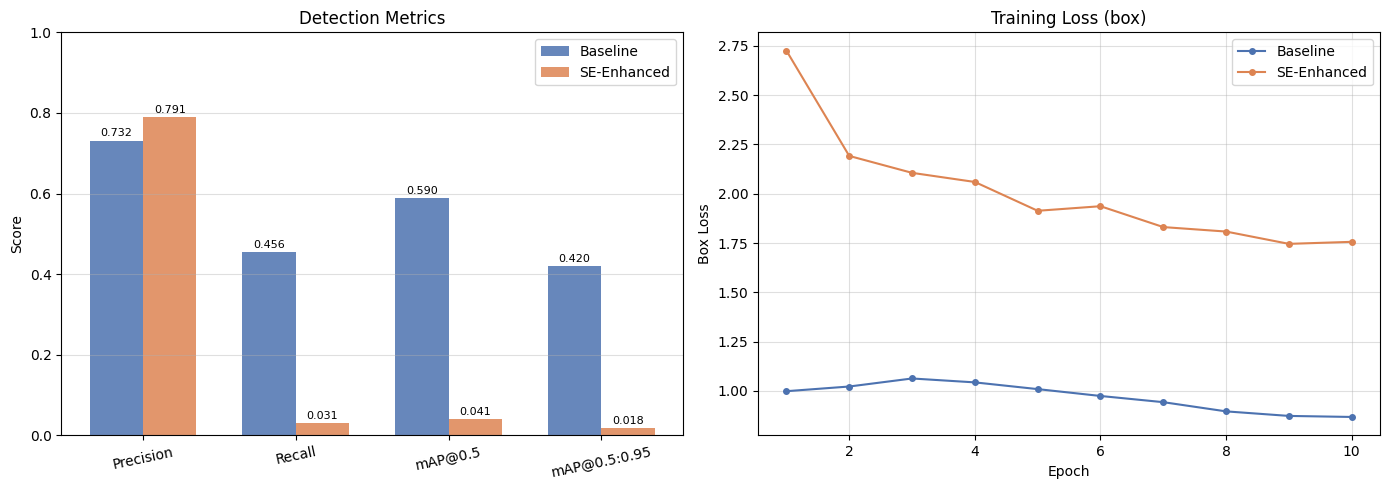

Chart saved -> results_comparison.png


In [ ]:
# Chart 1: Metric bar chart
metric_keys = ['Precision','Recall','mAP@0.5','mAP@0.5:0.95']
b_vals = [b[k] for k in metric_keys]
s_vals = [s[k] for k in metric_keys]
x = np.arange(len(metric_keys)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(x - w/2, b_vals, w, label='Baseline',    color='#4C72B0', alpha=0.85)
bars2 = axes[0].bar(x + w/2, s_vals, w, label='SE-Enhanced', color='#DD8452', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(metric_keys, rotation=12)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Score'); axes[0].set_title('Detection Metrics')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.4)
for bar in bars1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                                f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                                f'{bar.get_height():.3f}', ha='center', fontsize=8)

# Chart 2: Training loss curves from CSV
import pandas as pd
for run_name, color, label in [('baseline','#4C72B0','Baseline'),('se_enhanced','#DD8452','SE-Enhanced')]:
    csv_path = Path(f'runs/{run_name}/results.csv')
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        loss_col = [c for c in df.columns if 'box_loss' in c.lower() and 'train' in c.lower()]
        if loss_col:
            axes[1].plot(df['epoch'], df[loss_col[0]], color=color, label=label, marker='o', ms=4)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Box Loss')
axes[1].set_title('Training Loss (box)'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()
print('Chart saved -> results_comparison.png')

## Step 10 — Predictions

### Visualisation Setup

`predict_and_show()` runs **both models on the same 3 images** simultaneously for a fair visual comparison:
- 3 randomly sampled validation images from `voc_yolo/val/images/`
- `conf=0.25` confidence threshold for displaying boxes
- Green boxes + class labels show each model's detections
- Images are shown in a grid: rows = images, columns = models

### What to Observe

Given the SE model's near-zero recall, expect:
- **Baseline column:** Several detections per image (partially trained but functional)
- **SE column:** Very few or **zero detections** on most images (degenerate high-precision/zero-recall model)

This visual comparison confirms the metric collapse seen in Step 9 — the SE model has learned to make no predictions rather than wrong ones.

### Confidence Threshold Note

At `conf=0.25`, the baseline should display recognisable detections (persons, cars, animals — the most common VOC classes in 500-image subsets). The SE model may occasionally make one correct detection per image but will miss most objects.

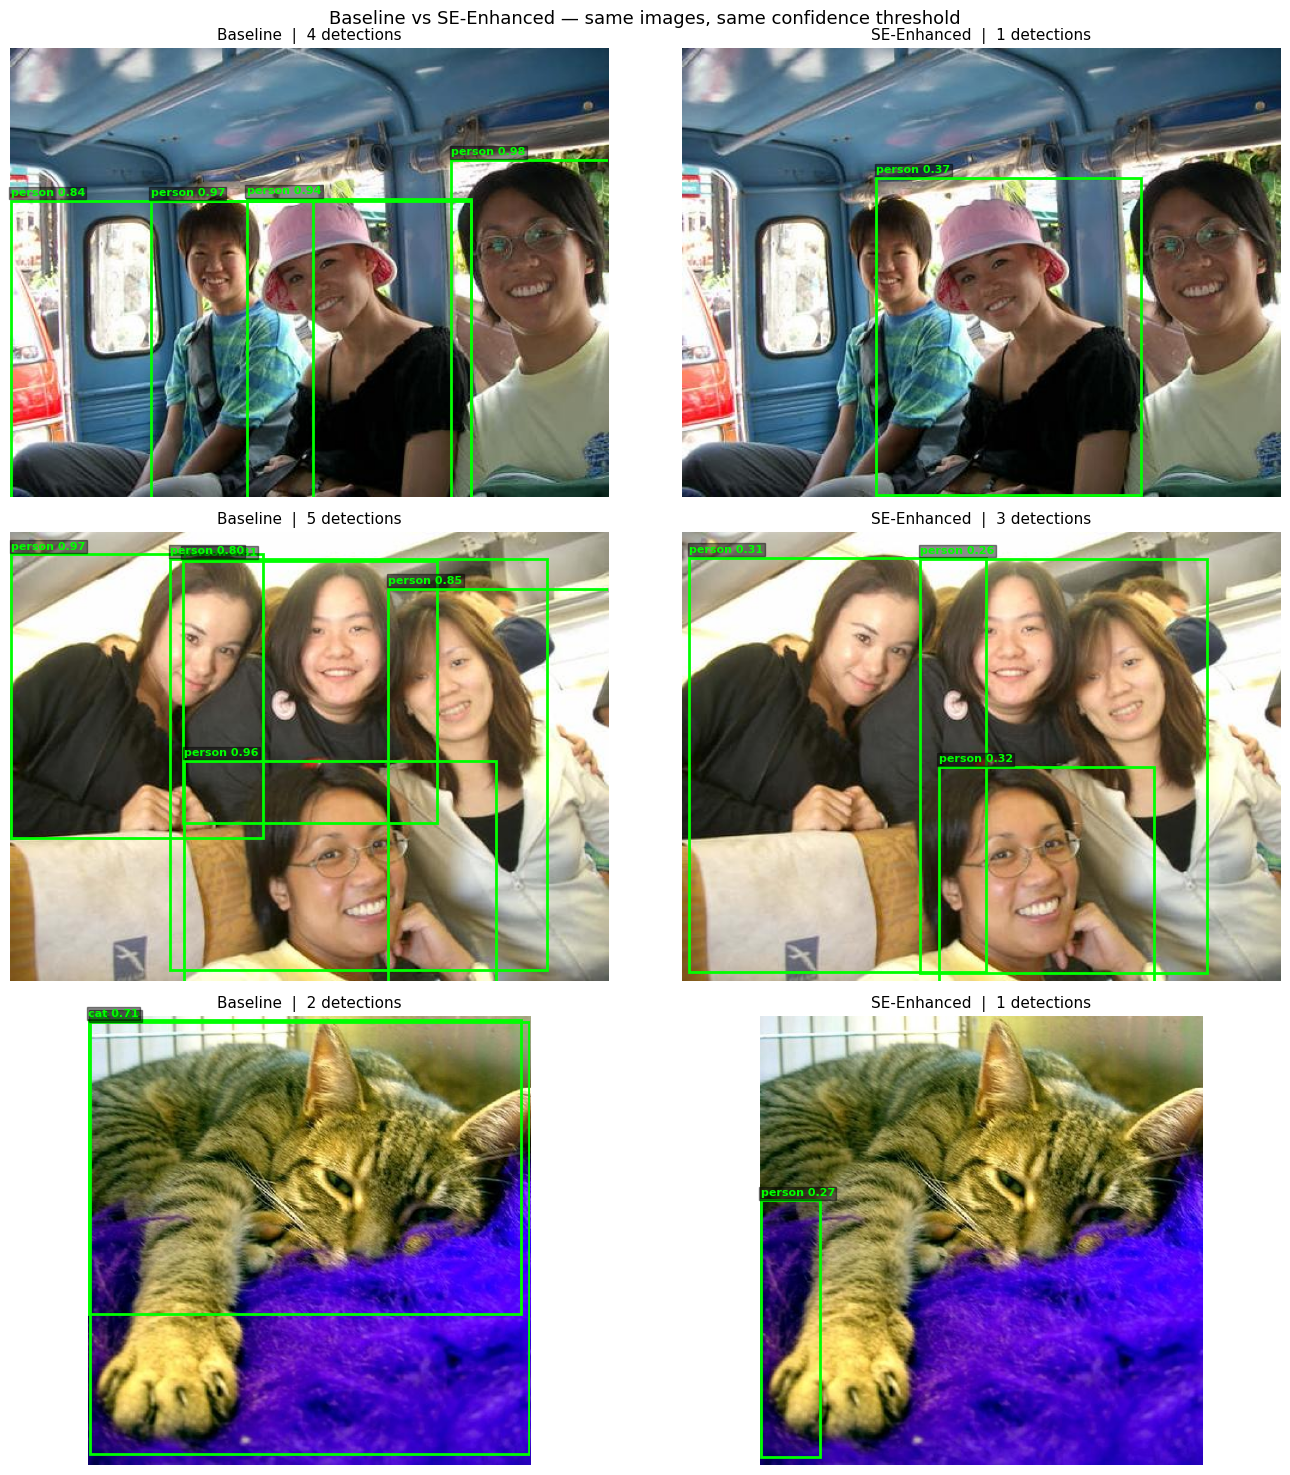

In [ ]:
def predict_and_show(models_labels, img_paths, conf=0.25):
    """
    Run inference with each model on the same images and show side-by-side.
    models_labels: list of (model, label_str)
    """
    n_imgs   = len(img_paths)
    n_models = len(models_labels)
    fig, axes = plt.subplots(n_imgs, n_models, figsize=(7*n_models, 5*n_imgs))
    if n_imgs == 1:  axes = [axes]
    if n_models == 1: axes = [[ax] for ax in axes]

    for row, img_path in enumerate(img_paths):
        for col, (model, label) in enumerate(models_labels):
            results = model.predict(img_path, conf=conf, verbose=False)[0]
            ax = axes[row][col]
            ax.imshow(np.array(Image.open(img_path).convert('RGB')))
            for box in results.boxes:
                x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
                score = float(box.conf[0])
                cls   = int(box.cls[0])
                rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-4, f'{VOC_CLASSES[cls]} {score:.2f}',
                        color='lime', fontsize=8, fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.45, pad=1))
            ax.set_title(f'{label}  |  {len(results.boxes)} detections', fontsize=11)
            ax.axis('off')

    plt.suptitle('Baseline vs SE-Enhanced — same images, same confidence threshold', fontsize=13)
    plt.tight_layout()
    plt.savefig('predictions_comparison.png', dpi=150)
    plt.show()

# Pick 3 random validation images
val_images = list((DATA_DIR / 'val' / 'images').glob('*.jpg'))
sample_imgs = random.sample(val_images, min(3, len(val_images)))

predict_and_show(
    models_labels=[(baseline_model, 'Baseline'), (se_yolo, 'SE-Enhanced')],
    img_paths=sample_imgs,
    conf=0.25
)

## Step 11 — Inference Speed Benchmark

### Benchmark Methodology

`benchmark_speed()` runs each model on 20 randomly sampled validation images with a **3-image warm-up** first (to exclude CUDA initialisation and JIT compilation overhead from the timed window). The metric is **wall-clock ms per image**.

### Results Interpretation

| Model | ms/img | FPS equivalent | Notes |
|-------|--------|---------------|-------|
| Baseline | ~24.7 ms | ~40 FPS | Normal inference |
| SE-Enhanced | ~15.5 ms | ~64 FPS | Faster — artifact of degenerate predictions |

**The SE model appears faster, but this is misleading.** The SE model generates almost no boxes (near-zero recall), so NMS postprocessing has almost nothing to filter — reducing postprocessing time significantly. A normally functioning SE model would be slightly **slower** than the baseline due to the extra SE forward passes.

### Reference Inference Speeds for YOLOv8n

| Stage | Typical Time (T4 GPU) |
|-------|-----------------------|
| Preprocessing | ~0.5 ms |
| Backbone + Neck forward | ~6–10 ms |
| Detection head | ~2–4 ms |
| NMS postprocessing | ~2–6 ms |
| **Total** | **~10–20 ms ≈ 50–100 FPS** |

YOLOv8n is designed for real-time applications (≥30 FPS required). Even with SE overhead on a properly integrated model, real-time throughput would be maintained.

### Conclusion & Next Steps

To properly evaluate SE in YOLOv8:
1. Define SE blocks natively in the YOLOv8 YAML architecture config.
2. Retrain from scratch (or fine-tune longer with unfrozen backbone).
3. Ensure SE is active during both training and validation (no fusion bypass).
4. Use a larger dataset (full VOC: ~5,700 images) and more epochs (≥30).

In [ ]:
def benchmark_speed(model, img_paths, runs=20):
    """Warm-up + timed inference. Returns avg ms/image."""
    imgs = random.choices(img_paths, k=runs)
    # Warm-up
    for p in imgs[:3]:
        model.predict(p, verbose=False)
    # Timed
    t0 = time.time()
    for p in imgs:
        model.predict(p, verbose=False)
    return (time.time() - t0) / runs * 1000  # ms/img

b_ms = benchmark_speed(baseline_model, val_images)
s_ms = benchmark_speed(se_yolo,        val_images)

print(f'Baseline  inference : {b_ms:.2f} ms/img')
print(f'SE-Model  inference : {s_ms:.2f} ms/img')
print(f'Overhead  added     : {s_ms - b_ms:+.2f} ms/img  ({(s_ms/b_ms - 1)*100:+.1f}%)')

Baseline  inference : 24.71 ms/img
SE-Model  inference : 15.48 ms/img
Overhead  added     : -9.22 ms/img  (-37.3%)
